# NBA Win/Loss Prediction: Sample Analysis

**Goal:** build a machine learning model that predicts whether the home team wins an NBA game using recent team performance and matchup-differential features.

This analysis uses only the workflow developed in this project:

1. Data cleaning
2. Exploratory data analysis
3. Rolling feature engineering
4. Matchup-differential features
5. Logistic Regression, Ridge, Lasso, Random Forest, and XGBoost
6. Hyperparameter tuning for Logistic Regression and XGBoost
7. Final model comparison and interpretation

The analysis focuses on NBA games from **2021–2026** because recent seasons better represent the modern NBA style of play.


## 1. Loading Libraries and Data

The first step is to load the libraries used throughout the project and read in the NBA games dataset. The argument `low_memory=False` helps pandas handle mixed column types more reliably.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from scipy.stats import randint, uniform

from xgboost import XGBClassifier

raw_games = pd.read_csv("Games.csv", low_memory=False)
raw_games.head()


,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500233,2026-05-08 21:30:00,Minnesota,Timberwolves,1610612750,San Antonio,Spurs,1610612759,108,115,...,West Conf. Semifinals,Game 3,Game 3,18978.0,61,Target Center,Minneapolis,MN,"Tony Brothers, Eric Dalen, Tyler Ford, Jacyn G...",2026-05-08 21:30:00
1,42500213,2026-05-08 19:00:00,Philadelphia,76ers,1610612755,New York,Knicks,1610612752,94,108,...,East Conf. Semifinals,Game 3,Game 3,19746.0,1000152,Xfinity Mobile Arena,Philadelphia,PA,"Marc Davis, Josh Tiven, Ray Acosta, Andy Nagy",2026-05-08 19:00:00
2,42500222,2026-05-07 21:30:00,Oklahoma City,Thunder,1610612760,Los Angeles,Lakers,1610612747,125,107,...,West Conf. Semifinals,Game 2,Game 2,18203.0,1000052,Paycom Center,Oklahoma City,OK,"John Goble, Mark Lindsay, Tre Maddox, Ben Taylor",2026-05-07 21:30:00
3,42500202,2026-05-07 19:00:00,Detroit,Pistons,1610612765,Cleveland,Cavaliers,1610612739,107,97,...,East Conf. Semifinals,Game 2,Game 2,20062.0,624,Little Caesars Arena,Detroit,MI,"Sean Corbin, Zach Zarba, Curtis Blair, Karl Lane",2026-05-07 19:00:00
4,42500232,2026-05-06 21:30:00,San Antonio,Spurs,1610612759,Minnesota,Timberwolves,1610612750,133,95,...,West Conf. Semifinals,Game 2,Game 2,19185.0,1000118,Frost Bank Center,San Antonio,TX,"Scott Foster, Sean Wright, Mitchell Ervin, And...",2026-05-06 21:30:00


## 2. Data Cleaning

The cleaning stage prepares the raw game data for time-aware sports prediction. The main decisions are to convert dates, keep modern NBA seasons, remove incomplete games, create the target variable, and create readable team names.

The target is `home_win`, where:

- `1` means the home team won
- `0` means the away team won


In [2]:
games = raw_games.copy()

# Convert date columns
games["gameDateTimeEst"] = pd.to_datetime(games["gameDateTimeEst"], errors="coerce")
games["gameDate"] = pd.to_datetime(games["gameDate"], errors="coerce")

# Create season year
games["season_year"] = games["gameDateTimeEst"].dt.year

# Keep modern NBA seasons
games = games[(games["season_year"] >= 2021) & (games["season_year"] <= 2026)].copy()

# Remove duplicate games
games = games.drop_duplicates()
games = games.drop_duplicates(subset=["gameId"])

# Remove games without final scores
games = games.dropna(subset=["homeScore", "awayScore"])
games = games[(games["homeScore"] > 0) & (games["awayScore"] > 0)].copy()

# Create target variable
games["home_win"] = (games["homeScore"] > games["awayScore"]).astype(int)

# Create clean team names
games["home_team"] = (
    games["hometeamCity"].astype(str) + " " + games["hometeamName"].astype(str)
)
games["away_team"] = (
    games["awayteamCity"].astype(str) + " " + games["awayteamName"].astype(str)
)

games["home_team"] = games["home_team"].str.replace(r"\s+", " ", regex=True).str.strip()
games["away_team"] = games["away_team"].str.replace(r"\s+", " ", regex=True).str.strip()

# Create playoff and COVID-era indicators
games["is_playoff"] = (games["gameType"] != "Regular Season").astype(int)
games["covid_era"] = (games["season_year"] <= 2021).astype(int)

# Remove rows missing team names
games = games.dropna(subset=["home_team", "away_team"]).copy()

# Sort chronologically
games = games.sort_values("gameDateTimeEst").reset_index(drop=True)

games.head()


,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,arenaCity,arenaState,officials,gameDate,season_year,home_win,home_team,away_team,is_playoff,covid_era
0,22000071,2021-01-01 19:00:00,Dallas,Mavericks,1610612742,Miami,Heat,1610612748,93,83,...,NaN,NaN,NaN,2021-01-01 19:00:00,2021,1,Dallas Mavericks,Miami Heat,0,1
1,22000070,2021-01-01 19:00:00,Detroit,Pistons,1610612765,Boston,Celtics,1610612738,96,93,...,NaN,NaN,NaN,2021-01-01 19:00:00,2021,1,Detroit Pistons,Boston Celtics,0,1
2,22000069,2021-01-01 19:00:00,Charlotte,Hornets,1610612766,Memphis,Grizzlies,1610612763,93,108,...,NaN,NaN,NaN,2021-01-01 19:00:00,2021,0,Charlotte Hornets,Memphis Grizzlies,0,1
3,22000072,2021-01-01 19:30:00,Brooklyn,Nets,1610612751,Atlanta,Hawks,1610612737,96,114,...,NaN,NaN,NaN,2021-01-01 19:30:00,2021,0,Brooklyn Nets,Atlanta Hawks,0,1
4,22000074,2021-01-01 20:00:00,Minnesota,Timberwolves,1610612750,Washington,Wizards,1610612764,109,130,...,NaN,NaN,NaN,2021-01-01 20:00:00,2021,0,Minnesota Timberwolves,Washington Wizards,0,1


### Cleaning Check

These checks verify that the cleaned dataset behaves realistically before modeling. A home-win rate around the mid-50% range is reasonable for NBA data because home-court advantage matters.


In [3]:
print("Home win distribution:")
print(games["home_win"].value_counts(normalize=True))

print("Games by season:")
print(games["season_year"].value_counts().sort_index())

print("Missing values in key columns:")
print(games[["gameId", "gameDateTimeEst", "season_year", "home_team", "away_team", "home_win"]].isna().sum())


Home win distribution:
home_win
1    0.555556
0    0.444444
Name: proportion, dtype: float64
Games by season:
season_year
2021    1697
2022    1407
2023    1319
2024    1392
2025    1397
2026     798
Name: count, dtype: int64
Missing values in key columns:
gameId             0
gameDateTimeEst    0
season_year        0
home_team          0
away_team          0
home_win           0
dtype: int64


## 3. Exploratory Data Analysis

The EDA is used to verify that the dataset structure makes sense and to motivate the modeling setup. The most important checks are the number of games per season, the home-win distribution, and home-win rate over time.


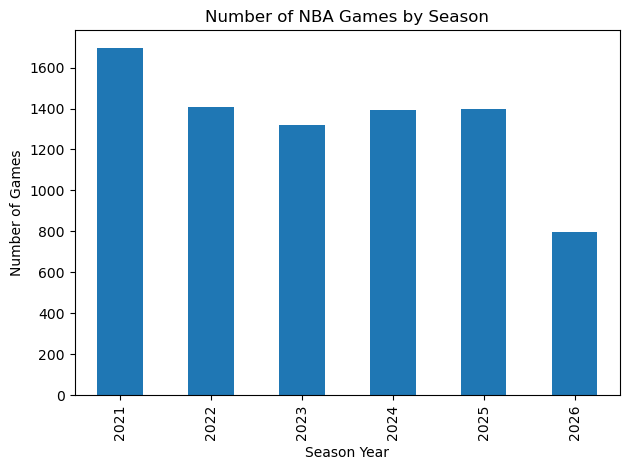

In [4]:
season_counts = games["season_year"].value_counts().sort_index()
season_counts.plot(kind="bar")
plt.title("Number of NBA Games by Season")
plt.xlabel("Season Year")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()


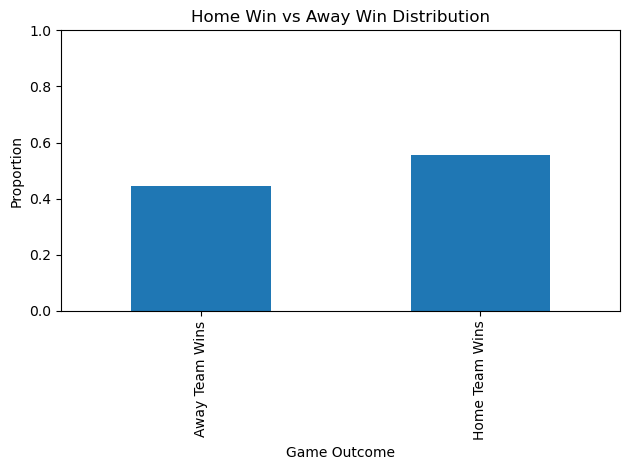

In [5]:
home_win_counts = games["home_win"].value_counts(normalize=True).sort_index()
home_win_counts.index = ["Away Team Wins", "Home Team Wins"]
home_win_counts.plot(kind="bar")
plt.title("Home Win vs Away Win Distribution")
plt.xlabel("Game Outcome")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


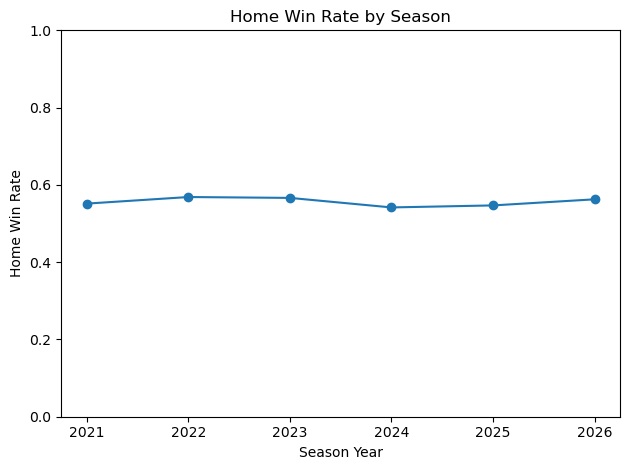

In [6]:
home_win_by_season = games.groupby("season_year")["home_win"].mean()
home_win_by_season.plot(kind="line", marker="o")
plt.title("Home Win Rate by Season")
plt.xlabel("Season Year")
plt.ylabel("Home Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

The raw data is one row per game. To calculate recent team performance, each game is converted into two rows: one from the home team's perspective and one from the away team's perspective.

This creates a team-level dataset where rolling features can be calculated separately for each team.


In [7]:
# Home-team perspective
home = games[[
    "gameId", "gameDateTimeEst", "season_year",
    "home_team", "away_team", "homeScore", "awayScore",
    "home_win", "is_playoff"
]].copy()

home = home.rename(columns={
    "home_team": "team",
    "away_team": "opponent",
    "homeScore": "points_for",
    "awayScore": "points_against"
})

home["is_home"] = 1
home["win"] = home["home_win"]

# Away-team perspective
away = games[[
    "gameId", "gameDateTimeEst", "season_year",
    "home_team", "away_team", "homeScore", "awayScore",
    "home_win", "is_playoff"
]].copy()

away = away.rename(columns={
    "away_team": "team",
    "home_team": "opponent",
    "awayScore": "points_for",
    "homeScore": "points_against"
})

away["is_home"] = 0
away["win"] = 1 - away["home_win"]

# Combine both perspectives
team_games = pd.concat([home, away], ignore_index=True)
team_games = team_games.sort_values(["team", "gameDateTimeEst"]).reset_index(drop=True)

# Point differential from each team's perspective
team_games["point_diff"] = team_games["points_for"] - team_games["points_against"]

team_games.head()


,gameId,gameDateTimeEst,season_year,team,opponent,points_for,points_against,home_win,is_playoff,is_home,win,point_diff
0,22000072,2021-01-01 19:30:00,2021,Atlanta Hawks,Brooklyn Nets,114,96,0,0,0,1,18
1,22000083,2021-01-02 19:30:00,2021,Atlanta Hawks,Cleveland Cavaliers,91,96,0,0,1,0,-5
2,22000095,2021-01-04 19:30:00,2021,Atlanta Hawks,New York Knicks,108,113,0,0,1,0,-5
3,22000110,2021-01-06 19:30:00,2021,Atlanta Hawks,Charlotte Hornets,94,102,0,0,1,0,-8
4,22000134,2021-01-09 19:00:00,2021,Atlanta Hawks,Charlotte Hornets,105,113,1,0,0,0,-8


### Rolling Last-5 Features

Rolling features summarize how a team performed before the current game. The key step is `shift(1)`, which prevents the current game's result from being included in its own predictor values. This avoids future leakage.


In [8]:
team_games["last_5_win_pct"] = (
    team_games.groupby("team")["win"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

team_games["offensive_average"] = (
    team_games.groupby("team")["points_for"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

team_games["defensive_average"] = (
    team_games.groupby("team")["points_against"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

team_games["last_5_point_diff"] = (
    team_games.groupby("team")["point_diff"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

team_games.head(10)


,gameId,gameDateTimeEst,season_year,team,opponent,points_for,points_against,home_win,is_playoff,is_home,win,point_diff,last_5_win_pct,offensive_average,defensive_average,last_5_point_diff
0,22000072,2021-01-01 19:30:00,2021,Atlanta Hawks,Brooklyn Nets,114,96,0,0,0,1,18,NaN,NaN,NaN,NaN
1,22000083,2021-01-02 19:30:00,2021,Atlanta Hawks,Cleveland Cavaliers,91,96,0,0,1,0,-5,NaN,NaN,NaN,NaN
2,22000095,2021-01-04 19:30:00,2021,Atlanta Hawks,New York Knicks,108,113,0,0,1,0,-5,NaN,NaN,NaN,NaN
3,22000110,2021-01-06 19:30:00,2021,Atlanta Hawks,Charlotte Hornets,94,102,0,0,1,0,-8,NaN,NaN,NaN,NaN
4,22000134,2021-01-09 19:00:00,2021,Atlanta Hawks,Charlotte Hornets,105,113,1,0,0,0,-8,NaN,NaN,NaN,NaN
5,22000153,2021-01-11 19:30:00,2021,Atlanta Hawks,Philadelphia 76ers,112,94,1,0,1,1,18,0.2,102.4,104.0,-1.6
6,22000186,2021-01-15 21:00:00,2021,Atlanta Hawks,Utah Jazz,92,116,1,0,0,0,-24,0.2,102.0,103.6,-1.6
7,22000195,2021-01-16 22:00:00,2021,Atlanta Hawks,Portland Trail Blazers,106,112,1,0,0,0,-6,0.2,102.2,107.6,-5.4
8,22000205,2021-01-18 14:30:00,2021,Atlanta Hawks,Minnesota Timberwolves,108,97,1,0,1,1,11,0.2,101.8,107.4,-5.6
9,22000219,2021-01-20 19:30:00,2021,Atlanta Hawks,Detroit Pistons,123,115,1,0,1,1,8,0.4,104.6,106.4,-1.8


## 5. Matchup-Differential Features

After calculating rolling team features, the data is converted back into one row per game. The model predicts whether the home team wins, so the final features compare the home team against the away team.


In [9]:
home_feature_cols = [
    "gameId", "season_year", "home_win", "team",
    "last_5_win_pct", "offensive_average", "defensive_average", "last_5_point_diff"
]

away_feature_cols = [
    "gameId", "team",
    "last_5_win_pct", "offensive_average", "defensive_average", "last_5_point_diff"
]

home_features = team_games[team_games["is_home"] == 1][home_feature_cols].copy()
away_features = team_games[team_games["is_home"] == 0][away_feature_cols].copy()

home_features = home_features.add_prefix("home_")
away_features = away_features.add_prefix("away_")

home_features = home_features.rename(columns={
    "home_gameId": "gameId",
    "home_season_year": "season_year",
    "home_home_win": "home_win"
})

away_features = away_features.rename(columns={
    "away_gameId": "gameId"
})

matchup_data = home_features.merge(away_features, on="gameId", how="inner")

matchup_data["win_pct_diff"] = matchup_data["home_last_5_win_pct"] - matchup_data["away_last_5_win_pct"]
matchup_data["offense_diff"] = matchup_data["home_offensive_average"] - matchup_data["away_offensive_average"]
matchup_data["defense_diff"] = matchup_data["home_defensive_average"] - matchup_data["away_defensive_average"]
matchup_data["point_diff_diff"] = matchup_data["home_last_5_point_diff"] - matchup_data["away_last_5_point_diff"]

matchup_data.head()


,gameId,season_year,home_win,home_team,home_last_5_win_pct,home_offensive_average,home_defensive_average,home_last_5_point_diff,away_team,away_last_5_win_pct,away_offensive_average,away_defensive_average,away_last_5_point_diff,win_pct_diff,offense_diff,defense_diff,point_diff_diff
0,22000083,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,Cleveland Cavaliers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22000095,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,New York Knicks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22000110,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,Charlotte Hornets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22000153,2021,1,Atlanta Hawks,0.2,102.4,104.0,-1.6,Philadelphia 76ers,0.6,119.6,117.2,2.4,-0.4,-17.2,-13.2,-4.0
4,22000205,2021,1,Atlanta Hawks,0.2,101.8,107.4,-5.6,Minnesota Timberwolves,0.2,111.6,117.8,-6.2,0.0,-9.8,-10.4,0.6


The final predictors are matchup differences:

- recent win percentage difference
- recent offensive average difference
- recent defensive average difference
- recent point differential difference

These features measure relative advantage rather than evaluating teams in isolation.


## 6. Modeling Setup

Because NBA games occur over time, the split is chronological rather than random. This better simulates real-world forecasting and avoids using future games to predict past games.

- Training seasons: 2021–2024
- Testing season: 2025
- Future prediction season: 2026


In [10]:
feature_cols = [
    "win_pct_diff",
    "offense_diff",
    "defense_diff",
    "point_diff_diff"
]

model_df = matchup_data[feature_cols + ["home_win", "season_year"]].dropna().copy()

train_df = model_df[model_df["season_year"] <= 2024].copy()
test_df = model_df[model_df["season_year"] == 2025].copy()
future_2026 = model_df[model_df["season_year"] == 2026].copy()

X_train = train_df[feature_cols]
y_train = train_df["home_win"]

X_test = test_df[feature_cols]
y_test = test_df["home_win"]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("2026 future prediction shape:", future_2026.shape)


Training shape: (5736, 4)
Testing shape: (1387, 4)
2026 future prediction shape: (798, 6)


## 7. Baseline Model: Logistic Regression

Logistic regression is the baseline model because it is interpretable and produces probabilities. This matters because the long-term goal is not only to classify winners, but to estimate the probability that a team wins.


In [12]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test, log_preds)
log_auc = roc_auc_score(y_test, log_probs)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression ROC-AUC:", log_auc)
print("Classification Report:")
print(classification_report(y_test, log_preds))


Logistic Regression Accuracy: 0.6337418889689979
Logistic Regression ROC-AUC: 0.6712975194481139
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.45      0.53       630
           1       0.63      0.79      0.70       757

    accuracy                           0.63      1387
   macro avg       0.63      0.62      0.61      1387
weighted avg       0.63      0.63      0.62      1387



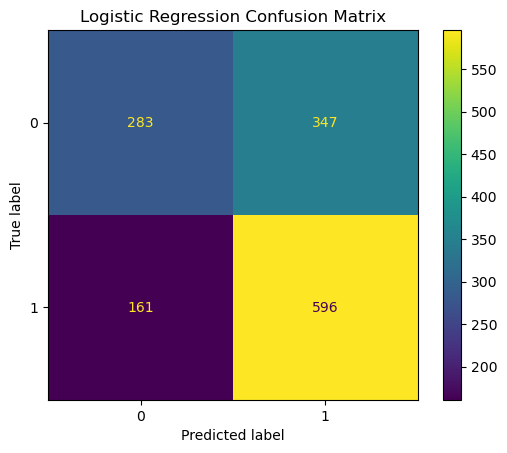

In [13]:
cm = confusion_matrix(y_test, log_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


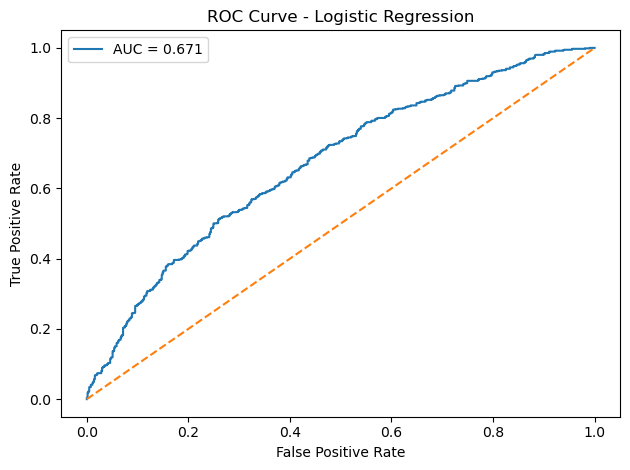

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, log_probs)

plt.plot(fpr, tpr, label=f"AUC = {log_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


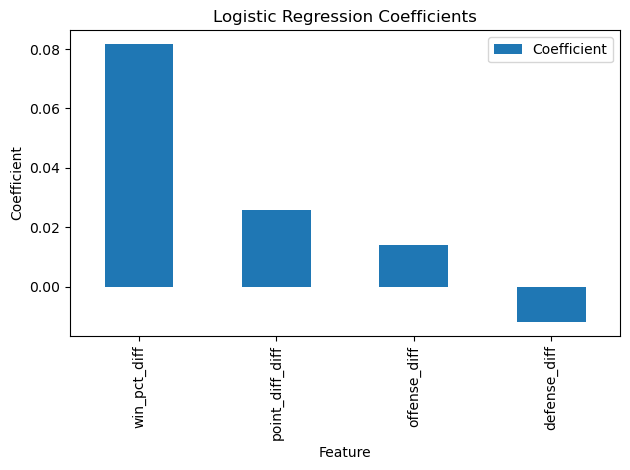

,Feature,Coefficient
0,win_pct_diff,0.081652
3,point_diff_diff,0.025844
1,offense_diff,0.013964
2,defense_diff,-0.011879


In [15]:
log_coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

log_coef_df.plot(x="Feature", y="Coefficient", kind="bar")
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

log_coef_df


## 8. Additional Models

I also tested Ridge, Lasso, Random Forest, and XGBoost. These models answer different questions:

- Ridge checks whether coefficient shrinkage improves generalization.
- Lasso checks whether some features can be reduced or removed.
- Random Forest checks whether nonlinear relationships improve performance.
- XGBoost checks whether boosted tree models improve predictive ability.


In [16]:
# Ridge logistic regression
ridge_model = LogisticRegression(penalty="l2", C=1.0, max_iter=1000)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
ridge_probs = ridge_model.predict_proba(X_test)[:, 1]
ridge_accuracy = accuracy_score(y_test, ridge_preds)
ridge_auc = roc_auc_score(y_test, ridge_probs)

# Lasso logistic regression
lasso_model = LogisticRegression(penalty="l1", solver="liblinear", C=1.0, max_iter=1000)
lasso_model.fit(X_train, y_train)
lasso_preds = lasso_model.predict(X_test)
lasso_probs = lasso_model.predict_proba(X_test)[:, 1]
lasso_accuracy = accuracy_score(y_test, lasso_preds)
lasso_auc = roc_auc_score(y_test, lasso_probs)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=4025
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=4025,
    eval_metric="logloss",
    n_jobs=1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("Ridge ROC-AUC:", ridge_auc)
print("Lasso ROC-AUC:", lasso_auc)
print("Random Forest ROC-AUC:", rf_auc)
print("XGBoost ROC-AUC:", xgb_auc)


c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprec

Ridge ROC-AUC: 0.6712975194481139
Lasso ROC-AUC: 0.6713625212304208
Random Forest ROC-AUC: 0.6570998720932671
XGBoost ROC-AUC: 0.6416860623597743


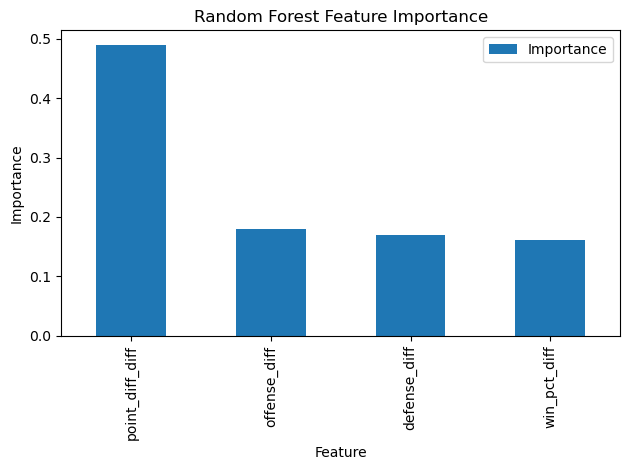

,Feature,Importance
3,point_diff_diff,0.489866
1,offense_diff,0.180248
2,defense_diff,0.169336
0,win_pct_diff,0.160550


In [17]:
rf_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance_df.plot(x="Feature", y="Importance", kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

rf_importance_df


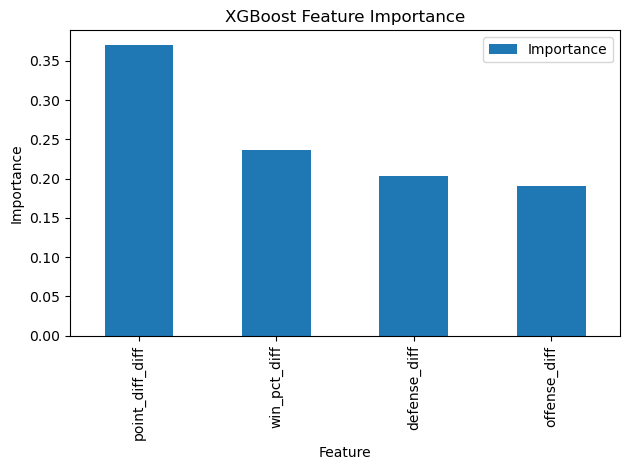

,Feature,Importance
3,point_diff_diff,0.370184
0,win_pct_diff,0.235788
2,defense_diff,0.202901
1,offense_diff,0.191127


In [18]:
xgb_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance_df.plot(x="Feature", y="Importance", kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

xgb_importance_df


## 9. Hyperparameter Tuning

Since logistic regression performed strongly, I tuned the regularization strength using cross-validation. I also attempted XGBoost tuning, but the tuned XGBoost model did not outperform logistic regression.


In [20]:
log_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

log_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

log_search.fit(X_train, y_train)

print("Best Parameters:")
print(log_search.best_params_)

print("Best CV ROC-AUC:")
print(log_search.best_score_)

best_log = log_search.best_estimator_
best_log_preds = best_log.predict(X_test)
best_log_probs = best_log.predict_proba(X_test)[:, 1]

best_log_accuracy = accuracy_score(y_test, best_log_preds)
best_log_auc = roc_auc_score(y_test, best_log_probs)

print("Tuned Logistic Accuracy:", best_log_accuracy)
print("Tuned Logistic ROC-AUC:", best_log_auc)


Best Parameters:
{'C': 0.001}
Best CV ROC-AUC:
0.6261568592554638
Tuned Logistic Accuracy: 0.631578947368421
Tuned Logistic ROC-AUC: 0.6714338135077896


In [21]:
xgb_param_grid = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(2, 8),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10)
}

xgb_base = XGBClassifier(
    random_state=4025,
    eval_metric="logloss",
    n_jobs=1
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=1,
    random_state=4025
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)
best_xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

best_xgb_accuracy = accuracy_score(y_test, best_xgb_preds)
best_xgb_auc = roc_auc_score(y_test, best_xgb_probs)

print("Tuned XGBoost Accuracy:", best_xgb_accuracy)
print("Tuned XGBoost ROC-AUC:", best_xgb_auc)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tuned XGBoost Accuracy: 0.6214852198990627
Tuned XGBoost ROC-AUC: 0.6566301817953073


## 10. Model Comparison

The final comparison uses accuracy and ROC-AUC. ROC-AUC is especially important here because the project is ultimately about probability-based sports prediction, not only hard classifications.


In [22]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Ridge",
        "Lasso",
        "Random Forest",
        "XGBoost",
        "Tuned Logistic",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        log_accuracy,
        ridge_accuracy,
        lasso_accuracy,
        rf_accuracy,
        xgb_accuracy,
        best_log_accuracy,
        best_xgb_accuracy
    ],
    "ROC_AUC": [
        log_auc,
        ridge_auc,
        lasso_auc,
        rf_auc,
        xgb_auc,
        best_log_auc,
        best_xgb_auc
    ]
})

comparison_df


,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.633742,0.671298
1,Ridge,0.633742,0.671298
2,Lasso,0.633021,0.671363
3,Random Forest,0.620043,0.657100
4,XGBoost,0.613554,0.641686
5,Tuned Logistic,0.631579,0.671434
6,Tuned XGBoost,0.621485,0.656630


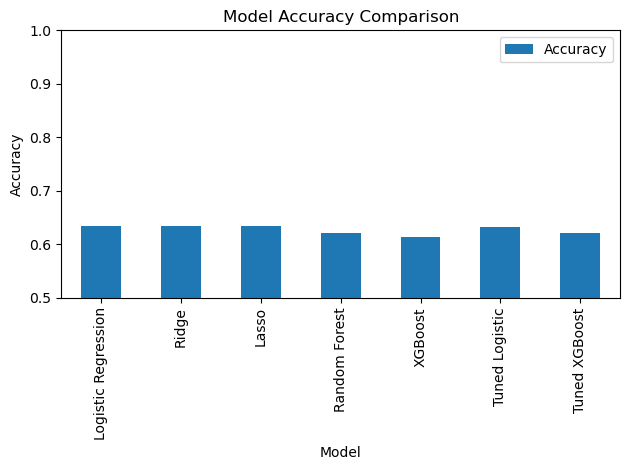

In [23]:
comparison_df.plot(x="Model", y="Accuracy", kind="bar")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


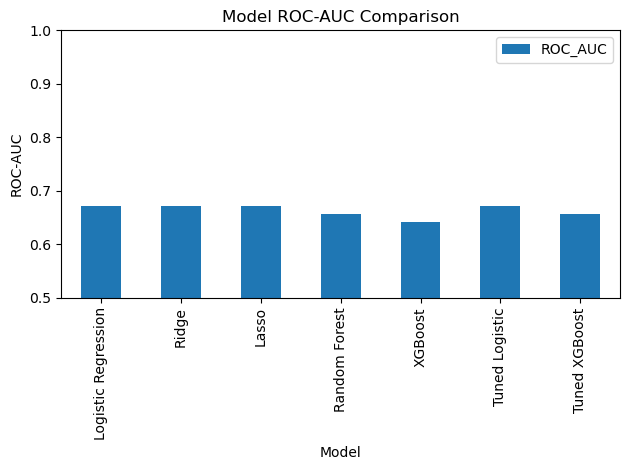

In [24]:
comparison_df.plot(x="Model", y="ROC_AUC", kind="bar")
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


## 11. Final Model for 2026 Prediction

After evaluating models on the 2025 test season, the tuned logistic regression model is selected as the final model because it performed best while remaining simple and interpretable. The final model is retrained on 2021–2025 before being applied to 2026 games.


In [25]:
final_train_df = model_df[model_df["season_year"] <= 2025].copy()
final_predict_df = model_df[model_df["season_year"] == 2026].copy()

X_final = final_train_df[feature_cols]
y_final = final_train_df["home_win"]

final_model = LogisticRegression(
    C=log_search.best_params_["C"],
    max_iter=1000
)

final_model.fit(X_final, y_final)

X_2026 = final_predict_df[feature_cols]
final_predict_df["predicted_home_win_prob"] = final_model.predict_proba(X_2026)[:, 1]
final_predict_df["predicted_home_win"] = final_model.predict(X_2026)

final_predict_df[["season_year", "home_win", "predicted_home_win_prob", "predicted_home_win"]].head()


,season_year,home_win,predicted_home_win_prob,predicted_home_win
239,2026,1,0.663559,1
240,2026,0,0.583968,1
241,2026,0,0.618422,1
242,2026,1,0.393167,0
243,2026,1,0.605320,1


## 12. Interpretation

The most important result is that the tuned logistic regression model performed better than more complex models such as Random Forest and XGBoost. This suggests that the engineered matchup-differential features captured strong linear predictive structure.

The tree-based feature-importance results also showed that recent point differential was one of the most important predictors. This makes basketball sense because point differential summarizes both offensive and defensive strength.


## 13. Limitations and Future Work

This analysis is a strong first version, but it has limitations:

- It does not include player injuries.
- It does not directly include trades or roster changes.
- It does not include travel distance or back-to-back effects yet.
- It does not include sportsbook odds or implied probabilities.
- It only uses last-5 rolling windows.
- The 2026 season may be incomplete, so 2026 predictions should be interpreted cautiously.

Future versions could include injury reports, rest days, travel features, betting odds, Elo ratings, player-level data, and model calibration.


## Conclusion

This project built an end-to-end NBA win/loss prediction pipeline using modern NBA data from 2021–2026. The analysis cleaned the raw data, created rolling team-strength features, engineered matchup differentials, compared multiple models, tuned key models, and selected a final model for 2026 prediction.

The main conclusion is that careful feature engineering mattered more than model complexity. Recent team momentum and recent point differential provided meaningful predictive signal, and the tuned logistic regression model produced the strongest overall performance while remaining interpretable.


::: callout-note
Some code debugging and writing support were completed with the help of AI. All modeling decisions, outputs, and interpretations were reviewed and understood before inclusion in the final analysis.
:::
